## APLN552: Problem 2 of Problem Set 1: Noun Classes in Tsez

In this problem, you'll implement a Naive Bayes classifier (we'll call this Model 0) as well as the Phonological Preference model (Model 3) from Gagliardi et al. (2012).  Then you'll apply Model 3 to three new sets of Tsez data: from younger children (4-7 year olds), older children (8-12 year olds), and adults, and analyze the pattern of learning revealed by the three.

### (a)

Implement `get_features_given_class` according to the docstring below.
This function computes the conditional probabilities $p(f_i|c_j)$
where $f_i$ is a feature value and $c_j$ is one of the noun classes. `get_features_given_class` will be used by both Model 0 and Model 3.

* For full credit on this problem, the `get_features_given_class` function should use an estimate of the expected value according to a Dirichlet distribution, as discussed in class, using the $\alpha$ as specified in the code prior to the function.

* For partial credit, you can use a Maximum Likelihood Estimate of the conditional probability in `get_features_given_class`.  You might also first implement the function using MLE in order to easily check your computations.

Make sure to go through and verify that your conditional probability computations make sense (ideally working them out by hand for a particular feature value). You are not required to show this here, but it is critical that you understand this to do well on this problem.

Call `get_feature_given_class('semantic')` to show the output of your function on semantic features.

In [ ]:
import numpy as np
from data import class_features_joint, noun_class_probabilities


alpha = 0.001 # This is the alpha constant for the Dirichlet estimates
              # of expected values of the conditional probabilities.
              # (alpha_i = alpha_j for all feature values i, j)
# You're welcome to experiment with different values of alpha, but:
# BE SURE THAT alpha IS SET TO .001 FOR THE RESULTS YOU TURN IN.

# You may also find it useful to have a variable for alpha * n_feature_values

def get_feature_given_class(feature_type):
    """
    feature_type: string in {"beg_phonological", "semantic"}

    Return a np.array of shape (n_feature_values, n_classes), where each index is the conditional
    probability of a feature value of feature_type given one of the four noun classes.
    """
    if feature_type not in class_features_joint:
       return (f"Unknown feature type: {feature_type}")

    joint_counts = np.array(class_features_joint[feature_type])
    class_probs = noun_class_probabilities

    n_feature_values = joint_counts.shape[0]
    n_classes = joint_counts.shape[1]

    alpha_value = alpha * n_feature_values

    conditional_probs = np.zeros_like(joint_counts, dtype=np.float64)

    for j in range(n_classes):
        column = joint_counts[:, j]
        smoothed_column = (column + alpha) / (np.sum(column) + alpha_value)
        conditional_probs[:, j] = smoothed_column

    return conditional_probs

get_feature_given_class('semantic')





array([[0.01765799, 0.0053132 , 0.12932853, 0.00362411],
       [0.01765799, 0.22406545, 0.00201927, 0.00362411],
       [0.94702602, 0.0053132 , 0.00201927, 0.00362411],
       [0.01765799, 0.76530815, 0.86663293, 0.98912767]])

### (b)

In the paper, Gagliardi et al. first present a Naive Bayes classifier as a baseline comparison to how children are classifying nouns in Tsez. Here, we will refer to this classifier as M0. Write a function `compute_trial_results_M0` that computes the results for each trial using equation (1) from the paper.

Call `compute_trial_results_M0` and print the result.

In [ ]:
import numpy as np
from data import features_by_trial, class_features_joint

def get_feature_given_class(feature_type):
    """Return P(feature|class) with Dirichlet smoothing (α=0.001)"""
    joint_counts = np.array(class_features_joint[feature_type])
    n_feature_values = joint_counts.shape[0]
    alpha = 0.001
    alpha_total = alpha * n_feature_values

    conditional_probs = np.zeros_like(joint_counts, dtype=np.float64)

    for j in range(joint_counts.shape[1]):
        column = joint_counts[:, j]
        smoothed = (column + alpha) / (np.sum(column) + alpha_total)
        conditional_probs[:, j] = smoothed

    return conditional_probs

def compute_trial_results_M0():
    """Naive Bayes classifier for Tsez noun classes"""
    semantic_probs = get_feature_given_class('semantic')
    phon_probs = get_feature_given_class('beg_phonological')

    n_trials = len(features_by_trial['semantic'])
    results = np.zeros((n_trials, 4))

    for i in range(n_trials):
        sem_id = features_by_trial['semantic'][i]
        phon_id = features_by_trial['beg_phonological'][i]


        sem_given_class = semantic_probs[sem_id]
        phon_given_class = phon_probs[phon_id]


        results[i] = (sem_given_class * phon_given_class) / np.sum(sem_given_class * phon_given_class)

    return results

M0_results = compute_trial_results_M0()
print(M0_results)

[[0.0116142  0.18909135 0.46515406 0.33414039]
 [0.00426488 0.08081886 0.25113256 0.6637837 ]
 [0.00643781 0.31050145 0.32195413 0.36110661]
 [0.98790007 0.00616791 0.00214639 0.00378564]
 [0.06475426 0.91439225 0.00754543 0.01330806]
 [0.11106925 0.03719112 0.82891308 0.02282655]
 [0.99422056 0.00209539 0.00172993 0.00195412]
 [0.13782528 0.76466944 0.01890972 0.07859557]
 [0.09533687 0.01254258 0.83775422 0.05436633]
 [0.11106925 0.03719112 0.82891308 0.02282655]
 [0.00643781 0.31050145 0.32195413 0.36110661]]


### (c)

The code for graphing `kid_answers` is provided and is called below. In a similar way, graph `M0_results` found in part b above for the feature combination of semantic female and beg phonological *r*. How do the two graphs compare? Is this what you would expect based on the results found in the paper?  (Your answer should be no longer than 100 words.)

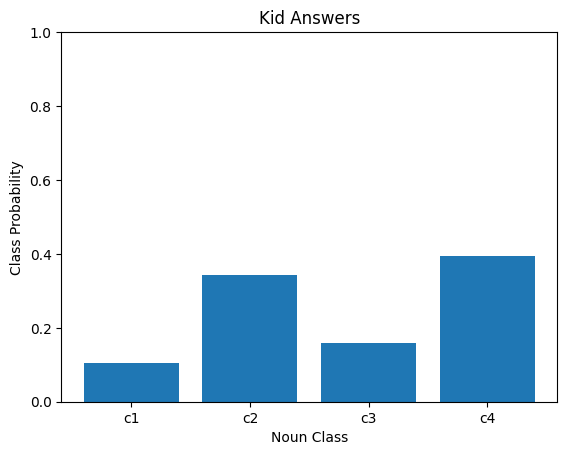

In [ ]:
from data import kid_answers, SEMANTIC_FEMALE, BEG_PHON_R
from provided_functions import visualise_results

visualise_results(kid_answers, semantic_filter=[SEMANTIC_FEMALE], beg_phonological_filter=[BEG_PHON_R],
                  title="Kid Answers")

In [ ]:
from provided_functions import visualise_results


ModuleNotFoundError: No module named 'provided_functions'

### (d)

Model 3 in the paper investigated the Phonological Preference Hypothesis. Implement M3 according to the function definitions below, which implement equation (4) from Gagliardi et al. (Note: it will probably be easiest to modify your code from part b.)

Call `compute_trial_results_M3` with a beta of 0.65 (the best results from the paper) and print the result.

In [ ]:
import numpy as np
from data import features_by_trial, class_features_joint, noun_class_probabilities

alpha = 0.001

def get_feature_given_class(feature_type):
    joint_counts = np.array(class_features_joint[feature_type])
    n_feature_values, n_classes = joint_counts.shape
    alpha_value = alpha * n_feature_values

    conditional_probs = np.zeros_like(joint_counts, dtype=np.float64)
    for j in range(n_classes):
        column = joint_counts[:, j]
        smoothed_column = (column + alpha) / (np.sum(column) + alpha_value)
        conditional_probs[:, j] = smoothed_column

    return conditional_probs

def compute_trial_results_phon_only():
    """
    Return an np.array of shape (n_trials, n_classes), where each row corresponds to
    a trial and each column corresponds to one of the four noun classes. The rows
    should be a probability distribution over the four noun classes for each trial
    using a Naive Bayes Classifier that looks at only phonological features
    (this computes the second term from formula (4) from Gagliardi et al.).
    """
    phon_probs = get_feature_given_class('beg_phonological')
    n_trials = len(features_by_trial['semantic'])
    n_classes = 4
    results = np.zeros((n_trials, n_classes))

    for i in range(n_trials):
        phon_index = features_by_trial['beg_phonological'][i]
        phon_given_class = phon_probs[phon_index]
        results[i] = phon_given_class / np.sum(phon_given_class)

    return results

def compute_trial_results_M0():
    """
    Classic Naive Bayes using both semantic and phonological features.
    """
    semantic_probs = get_feature_given_class('semantic')
    phon_probs = get_feature_given_class('beg_phonological')

    n_trials = len(features_by_trial['semantic'])
    n_classes = 4
    results = np.zeros((n_trials, n_classes))

    for i in range(n_trials):
        sem_index = features_by_trial['semantic'][i]
        phon_index = features_by_trial['beg_phonological'][i]

        sem_given_class = semantic_probs[sem_index]
        phon_given_class = phon_probs[phon_index]

        unnormalized = sem_given_class * phon_given_class
        results[i] = unnormalized / np.sum(unnormalized)

    return results

def compute_trial_results_M3(beta):
    """
    Return an np.array of shape (n_trials, n_classes), where each row corresponds to
    a trial and each column corresponds to one of the four noun classes. The rows
    should be a probability distribution over the four noun classes.

    The results should implement equation (4) from Gagliardi et al., using the beta
    parameter passed into the function.

    Hint: M3 is a mixture model, which you can implement as weighing the results of
    two different models.
    """
    results_M0 = compute_trial_results_M0()
    results_phon = compute_trial_results_phon_only()

    return beta * results_phon + (1 - beta) * results_M0

M3_results = compute_trial_results_M3(0.65)
print(M3_results)


[[0.24433389 0.15643982 0.35887399 0.2403523 ]
 [0.12151842 0.0807656  0.23190122 0.56581476]
 [0.15951798 0.28368517 0.27293229 0.28386456]
 [0.50302977 0.17716843 0.16099958 0.15880222]
 [0.17992874 0.49504695 0.16288924 0.16213507]
 [0.19613899 0.18802655 0.45036792 0.16546654]
 [0.58824612 0.09099124 0.19667554 0.1240871 ]
 [0.16826456 0.32011331 0.15062322 0.36099892]
 [0.15339361 0.0568689  0.4372188  0.35251868]
 [0.19613899 0.18802655 0.45036792 0.16546654]
 [0.15951798 0.28368517 0.27293229 0.28386456]]


### (e)

Graph the results from M3 (using `visualise_results`) for the feature combination of semantic female and phonological initial *r*.

Is this a better fit than M0? Briefly explain what this comparison suggests about the way that children process noun classes in Tsez.  (Your answer should be no longer than 100 words.)

### (f)

Below, we've graphed the results for `young_kid_answers`, `older_kid_answers`, and `adult_answers`, for the combination of semantic female and phonological initial *r*.

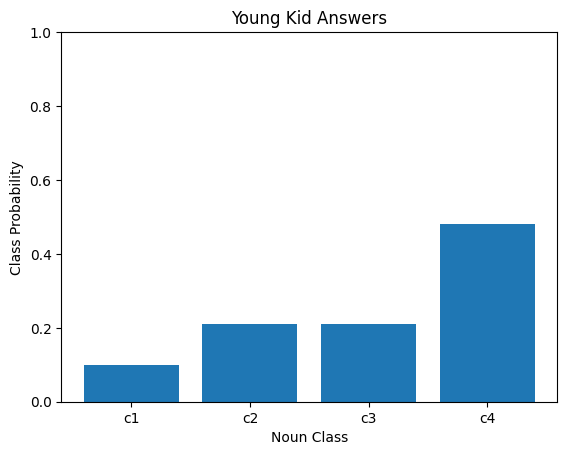

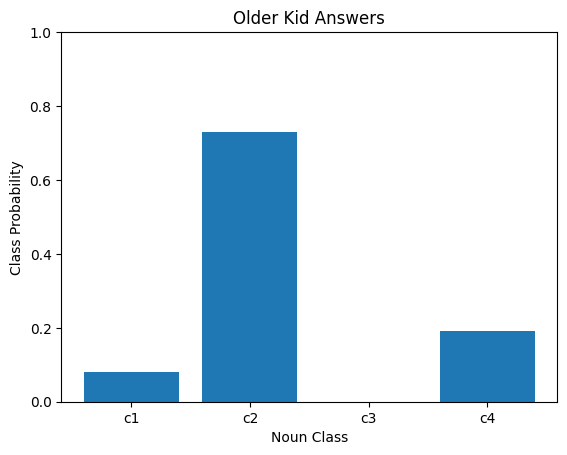

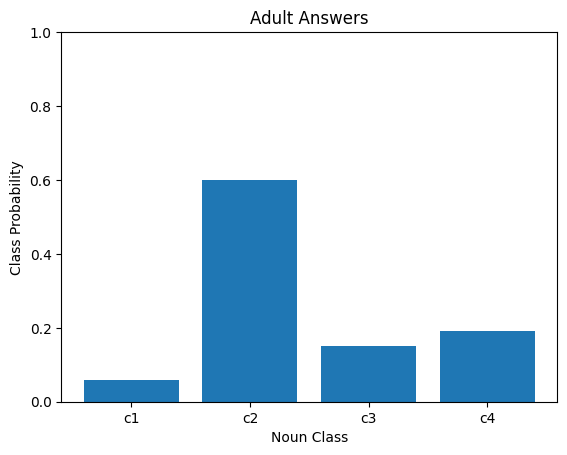

In [ ]:
from data import young_kid_answers, older_kid_answers, adult_answers, SEMANTIC_FEMALE, BEG_PHON_R
from provided_functions import visualise_results

visualise_results(young_kid_answers, semantic_filter=[SEMANTIC_FEMALE], beg_phonological_filter=[BEG_PHON_R],
                  title="Young Kid Answers")
visualise_results(older_kid_answers, semantic_filter=[SEMANTIC_FEMALE], beg_phonological_filter=[BEG_PHON_R],
                  title="Older Kid Answers")
visualise_results(adult_answers, semantic_filter=[SEMANTIC_FEMALE], beg_phonological_filter=[BEG_PHON_R],
                  title="Adult Answers")

### (f, continued)

Complete the function `compute_optimal_M3_parameters` below to find the optimal parameter values for M3.

Call `compute_optimal_M3_parameters` and print the optimal parameter values for each of `young_kid_answers`, `older_kid_answers`, and `adult_answers`.

In [ ]:
import numpy as np
from data import adult_answers, young_kid_answers, older_kid_answers
from provided_functions import sum_squared_error  # Removed compute_trial_results_M3 import

def compute_optimal_M3_parameters(gold_standard):
    best_param = 0
    lowest_error = float('inf')

    for param in np.arange(0, 1.01, 0.01):
        model_output = compute_trial_results_M3(param)
        error = sum_squared_error(model_output, gold_standard)
        if error < lowest_error:
            lowest_error = error
            best_param = param

    return best_param

print("Optimal for young_kid_answers: {:.4f}".format(compute_optimal_M3_parameters(gold_standard=young_kid_answers)))
print("Optimal for older_kid_answers: {:.4f}".format(compute_optimal_M3_parameters(gold_standard=older_kid_answers)))
print("Optimal for adult_answers: {:.4f}".format(compute_optimal_M3_parameters(gold_standard=adult_answers)))


Optimal for young_kid_answers: 0.4700
Optimal for older_kid_answers: 0.5400
Optimal for adult_answers: 0.5000


### (g)

Consider the various optimal parameter settings you found in part f, along with the three graphs of the human data we provided.

**1.** Do the optimal parameter settings you found fit your expectations given the developmental pattern of the human data?  Briefly explain why or why not.  (Your answer should be no longer than 100 words.)

**2.** What do the parameter settings and data suggest about the process of learning in children?  Relate what you found to ideas in the readings and discussed in class.  (Your answer should be no longer than 100 words.)  

